In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import os
import cupy as cp

dtype = np.dtype([
    ('o', np.float32, 3),
    ('d', np.float32, 3),
    ('beta_before_rgb', np.float32, 3),
    ('L_after_rgb', np.float32, 3),
    ('T_after', np.float32, 3),
    ('tMax', np.float32, 1)
])


print(os.getcwd())

/workspace/pbrt-v4-nn


In [2]:
with open("default_primitive_output_target.bin", "rb") as file:
    num_samples = np.frombuffer(file.read(8), dtype=np.uint64)[0]

    print(f"Number of samples: {num_samples}")

    data = np.frombuffer(file.read(), dtype=dtype)


print(f"Loaded {len(data)} samples")

o_gpu = cp.asarray(data['o'])
d_gpu = cp.asarray(data['d'])
beta_gpu = cp.asarray(data['beta_before_rgb'])
L_after_gpu = cp.asarray(data['L_after_rgb'])
T_after_gpu = cp.asarray(data['T_after'])
tMax_gpu = cp.asarray(data['tMax'])


Number of samples: 95274924
Loaded 95274924 samples


In [3]:
valid_mask = np.isfinite(data['tMax'].flatten())

valid_mask = cp.isfinite(tMax_gpu.flatten())
o_gpu = o_gpu[valid_mask]
d_gpu = d_gpu[valid_mask]
beta_gpu = beta_gpu[valid_mask]
L_after_gpu = L_after_gpu[valid_mask]
T_after_gpu = T_after_gpu[valid_mask]
tMax_gpu = tMax_gpu[valid_mask]


print(f"Kept {len(o_gpu)} / {len(data)} samples")

Kept 95274924 / 95274924 samples


In [4]:

import random as rand

batch_size = 25000

indices = cp.random.choice(len(o_gpu), size=min(batch_size, len(o_gpu)), replace=False)


random_batch = {
    'o': o_gpu[indices],
    'd': d_gpu[indices],
    'beta': beta_gpu[indices],
    'L_after': L_after_gpu[indices],
    'T_after': T_after_gpu[indices],
    'tMax': tMax_gpu[indices],
}


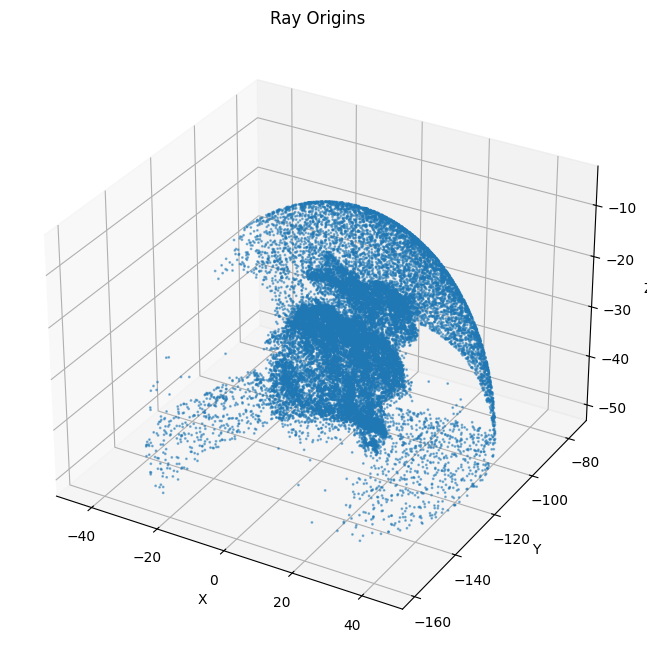

In [6]:
from mpl_toolkits.mplot3d import Axes3D


o_cpu = cp.asnumpy(random_batch['o'])

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(o_cpu[:, 0], o_cpu[:, 1], o_cpu[:, 2], s=1, alpha=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Ray Origins')

plt.show()


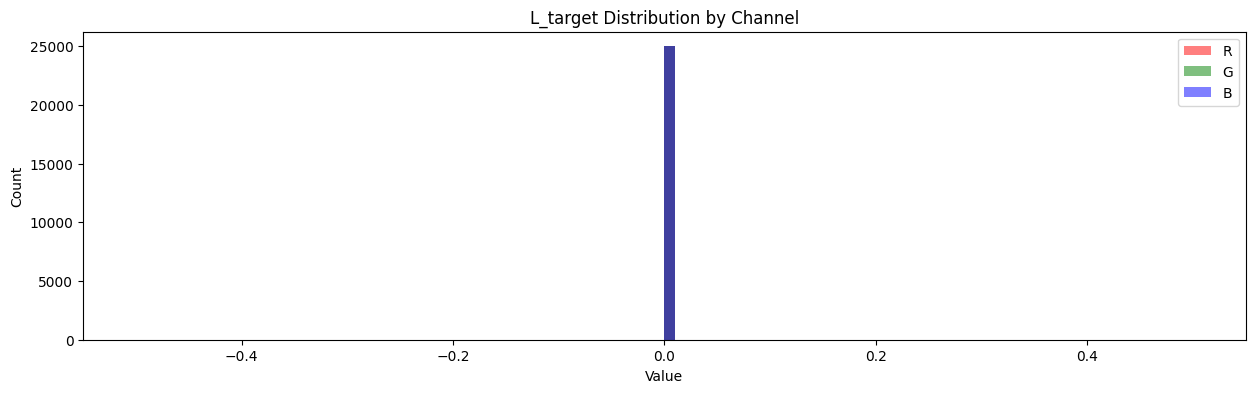

[[1.3150921  0.93386984 1.2587864 ]
 [0.99101466 0.93008006 1.1596149 ]
 [1.1325322  0.9943049  0.20165019]
 ...
 [1.4549022  0.9334676  0.575862  ]
 [1.4053258  0.9323831  0.9345329 ]
 [1.1356086  0.9824906  0.22551826]]


In [7]:


epsilon = 1e-6

L_target_gpu = cp.where(
    random_batch['beta'] > epsilon,
    random_batch['L_after'] / random_batch['beta'],
    0.0
)

L_target_cpu = cp.asnumpy(L_target_gpu)

fig, axes = plt.subplots(figsize=(15, 4))

axes.hist(L_target_cpu[:, 0], bins=100, alpha=0.5, label='R', color='red')
axes.hist(L_target_cpu[:, 1], bins=100, alpha=0.5, label='G', color='green')
axes.hist(L_target_cpu[:, 2], bins=100, alpha=0.5, label='B', color='blue')

axes.set_xlabel('Value')
axes.set_ylabel('Count')
axes.set_title('L_target Distribution by Channel')
axes.legend()

plt.show()

print(random_batch['beta'])


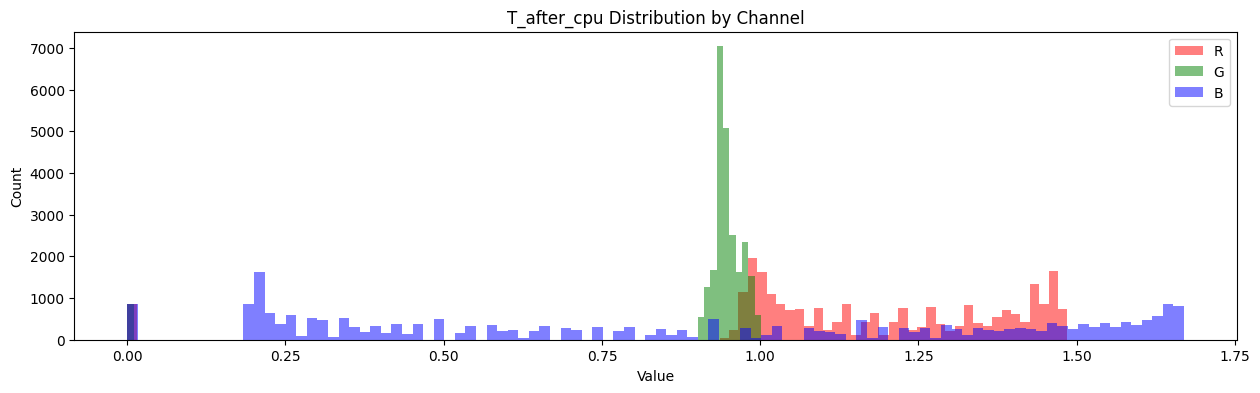

[[1.3150921  0.93386984 1.2587864 ]
 [0.991015   0.93008053 1.159615  ]
 [1.1325322  0.9943049  0.20165019]
 ...
 [1.4549026  0.9334675  0.575862  ]
 [1.4053261  0.93238324 0.93453294]
 [1.1356081  0.9824906  0.22551821]]


In [8]:



T_after_cpu = cp.asnumpy(random_batch['T_after'])

fig, axes = plt.subplots(figsize=(15, 4))

axes.hist(T_after_cpu[:, 0], bins=100, alpha=0.5, label='R', color='red')
axes.hist(T_after_cpu[:, 1], bins=100, alpha=0.5, label='G', color='green')
axes.hist(T_after_cpu[:, 2], bins=100, alpha=0.5, label='B', color='blue')

axes.set_xlabel('Value')

axes.set_ylabel('Count')
axes.set_title('T_after_cpu Distribution by Channel')
axes.legend()

plt.show()

print(T_after_cpu)


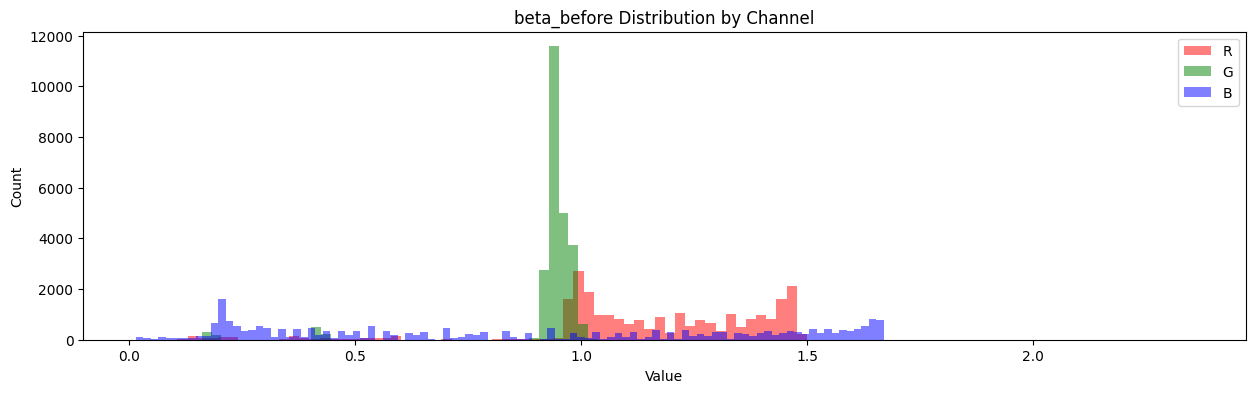

[[1.3150921  0.93386984 1.2587864 ]
 [0.99101466 0.93008006 1.1596149 ]
 [1.1325322  0.9943049  0.20165019]
 ...
 [1.4549022  0.9334676  0.575862  ]
 [1.4053258  0.9323831  0.9345329 ]
 [1.1356086  0.9824906  0.22551826]]


In [9]:



beta_before = cp.asnumpy(random_batch['beta'])

fig, axes = plt.subplots(figsize=(15, 4))

axes.hist(beta_before[:, 0], bins=100, alpha=0.5, label='R', color='red')
axes.hist(beta_before[:, 1], bins=100, alpha=0.5, label='G', color='green')
axes.hist(beta_before[:, 2], bins=100, alpha=0.5, label='B', color='blue')

axes.set_xlabel('Value')

axes.set_ylabel('Count')
axes.set_title('beta_before Distribution by Channel')
axes.legend()

plt.show()

print(beta_before)


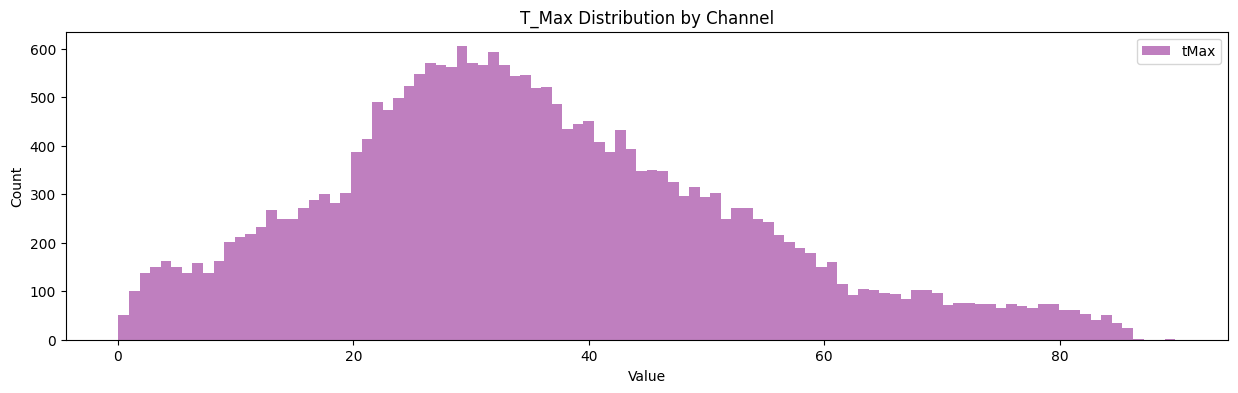

[[81.10189 ]
 [10.160454]
 [29.601234]
 ...
 [42.78003 ]
 [38.78027 ]
 [40.967422]]


In [10]:
# TMax value distribution


tMax_cpu = cp.asnumpy(random_batch['tMax'])

tMax_fig, tMax_axes = plt.subplots(figsize=(15, 4))


tMax_axes.hist(tMax_cpu, bins=100, alpha=0.5, label='tMax', color='purple')


tMax_axes.set_xlabel('Value')

tMax_axes.set_ylabel('Count')
tMax_axes.set_title('T_Max Distribution by Channel')
tMax_axes.legend()

plt.show()

print(tMax_cpu)


In [ ]:
# TODO create a 3D plot to show rayDirections and potentially tMax as well